# EDA — Paso 1: Exploración de `application_train`

**Objetivo:** Entender la tabla central del problema.

1. Cargar los datos y entender su forma
2. Evaluar la calidad (nulos, duplicados, basura)
3. Explorar la distribución de la TARGET 
4. Hacer un barrido de las features numéricas y categóricas
5. Identificar correlaciones clave con la TARGET

---
## 1. Setup

Imports y configuración global.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

# Configuración global
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', '{:.4f}'.format)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 100

---
## 2. Carga de datos `application_train.csv`

- Cada fila = 1 solicitud de préstamo.
- Cada columna = 1 característica del cliente o la solicitud.

In [3]:
df = pd.read_csv('../data/raw/application_train.csv')

print(f'Filas:      {df.shape[0]:,}')
print(f'Columnas:   {df.shape[1]}')
print(f'Memoria:    {df.memory_usage(deep=True).sum() / 1e6:.1f} MB')
print(f'ID únicos:  {df["SK_ID_CURR"].nunique():,}')

Filas:      307,511
Columnas:   122
Memoria:    562.8 MB
ID únicos:  307,511


In [4]:
df.head()

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,ORGANIZATION_TYPE,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,APARTMENTS_AVG,BASEMENTAREA_AVG,YEARS_BEGINEXPLUATATION_AVG,YEARS_BUILD_AVG,COMMONAREA_AVG,ELEVATORS_AVG,ENTRANCES_AVG,FLOORSMAX_AVG,FLOORSMIN_AVG,LANDAREA_AVG,LIVINGAPARTMENTS_AVG,LIVINGAREA_AVG,NONLIVINGAPARTMENTS_AVG,NONLIVINGAREA_AVG,APARTMENTS_MODE,BASEMENTAREA_MODE,YEARS_BEGINEXPLUATATION_MODE,YEARS_BUILD_MODE,COMMONAREA_MODE,ELEVATORS_MODE,ENTRANCES_MODE,FLOORSMAX_MODE,FLOORSMIN_MODE,LANDAREA_MODE,LIVINGAPARTMENTS_MODE,LIVINGAREA_MODE,NONLIVINGAPARTMENTS_MODE,NONLIVINGAREA_MODE,APARTMENTS_MEDI,BASEMENTAREA_MEDI,YEARS_BEGINEXPLUATATION_MEDI,YEARS_BUILD_MEDI,COMMONAREA_MEDI,ELEVATORS_MEDI,ENTRANCES_MEDI,FLOORSMAX_MEDI,FLOORSMIN_MEDI,LANDAREA_MEDI,LIVINGAPARTMENTS_MEDI,LIVINGAREA_MEDI,NONLIVINGAPARTMENTS_MEDI,NONLIVINGAREA_MEDI,FONDKAPREMONT_MODE,HOUSETYPE_MODE,TOTALAREA_MODE,WALLSMATERIAL_MODE,EMERGENCYSTATE_MODE,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0000,406597.5000,24700.5000,351000.0000,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.0188,-9461,-637,-3648.0000,-2120,NaN,1,1,0,1,1,0,Laborers,1.0000,2,2,WEDNESDAY,10,0,0,0,0,0,0,Business Entity Type 3,0.0830,0.2629,0.1394,0.0247,0.0369,0.9722,0.6192,0.0143,0.0000,0.0690,0.0833,0.1250,0.0369,0.0202,0.0190,0.0000,0.0000,0.0252,0.0383,0.9722,0.6341,0.0144,0.0000,0.0690,0.0833,0.1250,0.0377,0.0220,0.0198,0.0000,0.0000,0.0250,0.0369,0.9722,0.6243,0.0144,0.0000,0.0690,0.0833,0.1250,0.0375,0.0205,0.0193,0.0000,0.0000,reg oper account,block of flats,0.0149,"Stone, brick",No,2.0000,2.0000,2.0000,2.0000,-1134.0000,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000
1,100003,0,Cash loans,F,N,N,0,270000.0000,1293502.5000,35698.5000,1129500.0000,Family,State servant,Higher education,Married,House / apartment,0.0035,-16765,-1188,-1186.0000,-291,NaN,1,1,0,1,1,0,Core staff,2.0000,1,1,MONDAY,11,0,0,0,0,0,0,School,0.3113,0.6222,NaN,0.0959,0.0529,0.9851,0.7960,0.0605,0.0800,0.0345,0.2917,0.3333,0.0130,0.0773,0.0549,0.0039,0.0098,0.0924,0.0538,0.9851,0.8040,0.0497,0.0806,0.0345,0.2917,0.3333,0.0128,0.0790,0.0554,0.0000,0.0000,0.0968,0.0529,0.9851,0.7987,0.0608,0.0800,0.0345,0.2917,0.3333,0.0132,0.0787,0.0558,0.0039,0.0100,reg oper account,block of flats,0.0714,Block,No,1.0000,0.0000,1.0000,0.0000,-828.0000,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
2,100004,0,Revolving loans,M,Y,Y,0,67500.0000,135000.0000,6750.0000,135000.0000,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.0100,-19046,-225,-4260.0000,-2531,26.0000,1,1,1,1,1,0,Laborers,1.0000,2,2,MONDAY,9,0,0,0,0,0,0,Government,NaN,0.5559,0.

---
## 3. Estructura del dataset



In [5]:
# Info general: tipos, nulos, conteo
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Columns: 122 entries, SK_ID_CURR to AMT_REQ_CREDIT_BUREAU_YEAR
dtypes: float64(65), int64(41), str(16)
memory usage: 286.2 MB


In [7]:
# Estadísticas de columnas numéricas
df.describe().T

,count,mean,std,min,25%,50%,75%,max
SK_ID_CURR,307511.0000,278180.5186,102790.1753,100002.0000,189145.5000,278202.0000,367142.5000,456255.0000
TARGET,307511.0000,0.0807,0.2724,0.0000,0.0000,0.0000,0.0000,1.0000
CNT_CHILDREN,307511.0000,0.4171,0.7221,0.0000,0.0000,0.0000,1.0000,19.0000
AMT_INCOME_TOTAL,307511.0000,168797.9193,237123.1463,25650.0000,112500.0000,147150.0000,202500.0000,117000000.0000
AMT_CREDIT,307511.0000,599025.9997,402490.7770,45000.0000,270000.0000,513531.0000,808650.0000,4050000.0000
...,...,...,...,...,...,...,...,...
AMT_REQ_CREDIT_BUREAU_DAY,265992.0000,0.0070,0.1108,0.0000,0.0000,0.0000,0.0000,9.0000
AMT_REQ_CREDIT_BUREAU_WEEK,265992.0000,0.0344,0.2047,0.0000,0.0000,0.0000,0.0000,8.0000
AMT_REQ_CREDIT_BUREAU_MON,265992.0000,0.2674,0.9160,0.0000,0.0000,0.0000,0.0000,27.0000
AMT_REQ_CREDIT_BUREAU_QRT,265992.0000,0.2655,0.7941,0.0000,0.0000,0.0000,0.0000,261.0000


In [9]:
# Estadísticas de columnas categóricas / objeto
df.describe(include='object').T

,count,unique,top,freq
NAME_CONTRACT_TYPE,307511,2,Cash loans,278232
CODE_GENDER,307511,3,F,202448
FLAG_OWN_CAR,307511,2,N,202924
FLAG_OWN_REALTY,307511,2,Y,213312
NAME_TYPE_SUITE,306219,7,Unaccompanied,248526
NAME_INCOME_TYPE,307511,8,Working,158774
NAME_EDUCATION_TYPE,307511,5,Secondary / secondary special,218391
NAME_FAMILY_STATUS,307511,6,Married,196432
NAME_HOUSING_TYPE,307511,6,House / apartment,272868
OCCUPATION_TYPE,211120,18,Laborers,55186


### Separar features por tipo

Separar las columnas en numéricas y categóricas.

In [10]:
# Excluimos IDs y la target
ID_COL = 'SK_ID_CURR'
TARGET_COL = 'TARGET'

features = [c for c in df.columns if c not in [ID_COL, TARGET_COL]]

num_cols = df[features].select_dtypes(include=[np.number]).columns.tolist()
cat_cols = df[features].select_dtypes(include=['object']).columns.tolist()

print(f'Numéricas:   {len(num_cols)}')
print(f'Categóricas: {len(cat_cols)}')
print(f'Target:      1 ({TARGET_COL})')
print(f'ID:          1 ({ID_COL})')

Numéricas:   104
Categóricas: 16
Target:      1 (TARGET)
ID:          1 (SK_ID_CURR)


---
## 4. Calidad de datos

Preguntas clave:
- ¿Cuántos nulos hay?
- ¿Hay filas repetidas?
- ¿Hay columnas indiscernibles?

### 4.1 Valores nulos

In [11]:
# Nulos por columna, ordenados de mayor a menor
nulls = df.isnull().sum()
nulls_pct = (nulls / len(df) * 100).round(2)

null_df = pd.DataFrame({
    'nulos': nulls,
    'pct': nulls_pct
}).query('nulos > 0').sort_values('pct', ascending=False)

print(f'Columnas con nulos: {len(null_df)} de {df.shape[1]}')
print(f'\nTop 20 con más nulos:')
null_df.head(20)

Columnas con nulos: 67 de 122

Top 20 con más nulos:


,nulos,pct
COMMONAREA_MEDI,214865,69.8700
COMMONAREA_MODE,214865,69.8700
COMMONAREA_AVG,214865,69.8700
NONLIVINGAPARTMENTS_MODE,213514,69.4300
NONLIVINGAPARTMENTS_MEDI,213514,69.4300
NONLIVINGAPARTMENTS_AVG,213514,69.4300
FONDKAPREMONT_MODE,210295,68.3900
LIVINGAPARTMENTS_AVG,210199,68.3500
LIVINGAPARTMENTS_MEDI,210199,68.3500
LIVINGAPARTMENTS_MODE,210199,68.3500


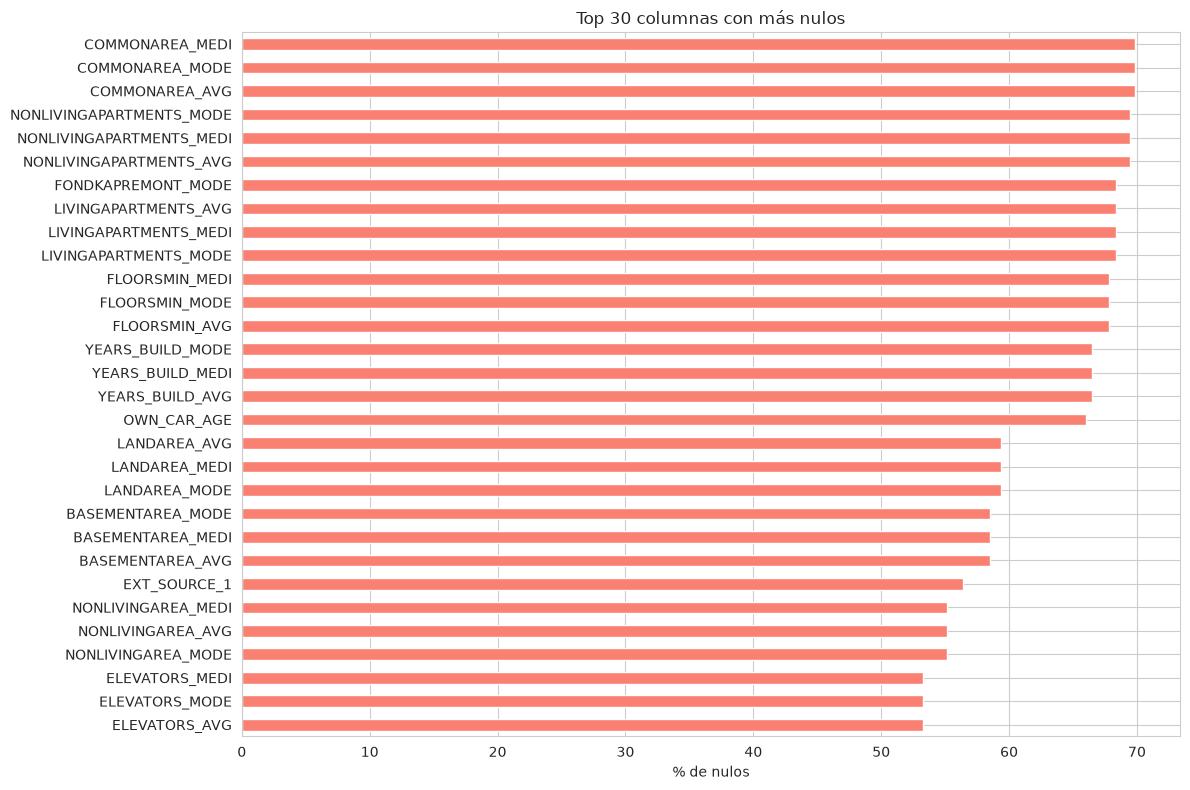

In [12]:
# Visualización de nulos
fig, ax = plt.subplots(figsize=(12, 8))
null_df['pct'].head(30).plot(kind='barh', ax=ax, color='salmon')
ax.set_xlabel('% de nulos')
ax.set_title('Top 30 columnas con más nulos')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

### 4.2 Filas repetidos

In [13]:
dups = df.duplicated().sum()
print(f'Filas duplicadas: {dups:,} ({dups/len(df)*100:.2f}%)')

# Verificar que cada ID es único
id_dups = df[ID_COL].duplicated().sum()
print(f'IDs duplicados:   {id_dups:,}')

Filas duplicadas: 0 (0.00%)
IDs duplicados:   0


### 4.3 Columnas indiscernibles

Si una columna tiene un solo valor, no aporta información.

In [14]:
const_cols = [c for c in features if df[c].nunique() <= 1]
print(f'Columnas constantes: {len(const_cols)}')
if const_cols:
    print(f'  → {const_cols}')
else:
    print('  → Ninguna. Todas las columnas tienen variabilidad.')

Columnas constantes: 0
  → Ninguna. Todas las columnas tienen variabilidad.


---
## 5. Distribución de la TARGET

- `0` = Pagó el préstamo (clase mayoritaria)
- `1` = Default / impago (clase minoritaria)


In [15]:
# Conteo y proporción
target_counts = df[TARGET_COL].value_counts()
target_pct = df[TARGET_COL].value_counts(normalize=True) * 100

print('Distribución de la TARGET:')
print(f'  0 (Pagó):       {target_counts[0]:,} ({target_pct[0]:.2f}%)')
print(f'  1 (Default):    {target_counts[1]:,} ({target_pct[1]:.2f}%)')
print(f'\nRatio de desbalanceo: 1:{target_counts[0]//target_counts[1]}')

Distribución de la TARGET:
  0 (Pagó):       282,686 (91.93%)
  1 (Default):    24,825 (8.07%)

Ratio de desbalanceo: 1:11


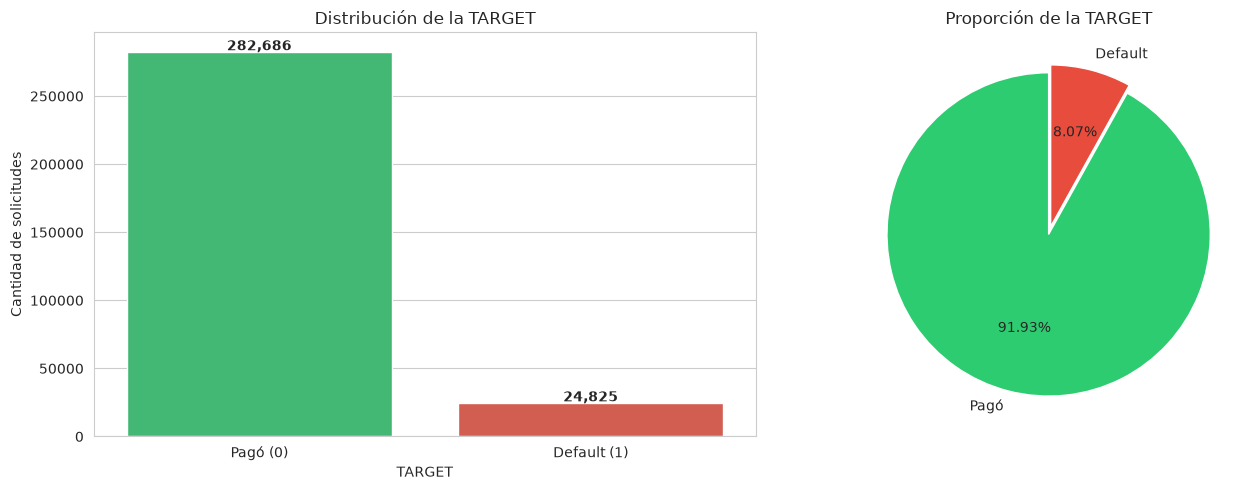

In [16]:
# Visualización
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Countplot
colors = ['#2ecc71', '#e74c3c']
sns.countplot(x=df[TARGET_COL], palette=colors, ax=axes[0])
axes[0].set_xticklabels(['Pagó (0)', 'Default (1)'])
axes[0].set_title('Distribución de la TARGET')
axes[0].set_ylabel('Cantidad de solicitudes')

# Agregar conteos encima de las barras
for i, v in enumerate(target_counts.values):
    axes[0].text(i, v + 1000, f'{v:,}', ha='center', fontweight='bold')

# Pie chart
axes[1].pie(target_counts.values, labels=['Pagó', 'Default'], 
            autopct='%1.2f%%', colors=colors, startangle=90,
            explode=(0, 0.05))
axes[1].set_title('Proporción de la TARGET')

plt.tight_layout()
plt.show()

### Esto significa:

- **NO usar accuracy** como métrica principal 
- Usar **AUC-ROC**, **F1-score**, o **Precision-Recall** 
- Considerar técnicas de balanceo 

---
## 6. Análisis univariado — Numéricas

Para cada feature numérica, vemos su distribución. Buscamos:
- **Skewness** (asimetría)
- **Outliers** extremos
- **Valores anómalos** (negativos donde no debería haber o ceros sospechosos)

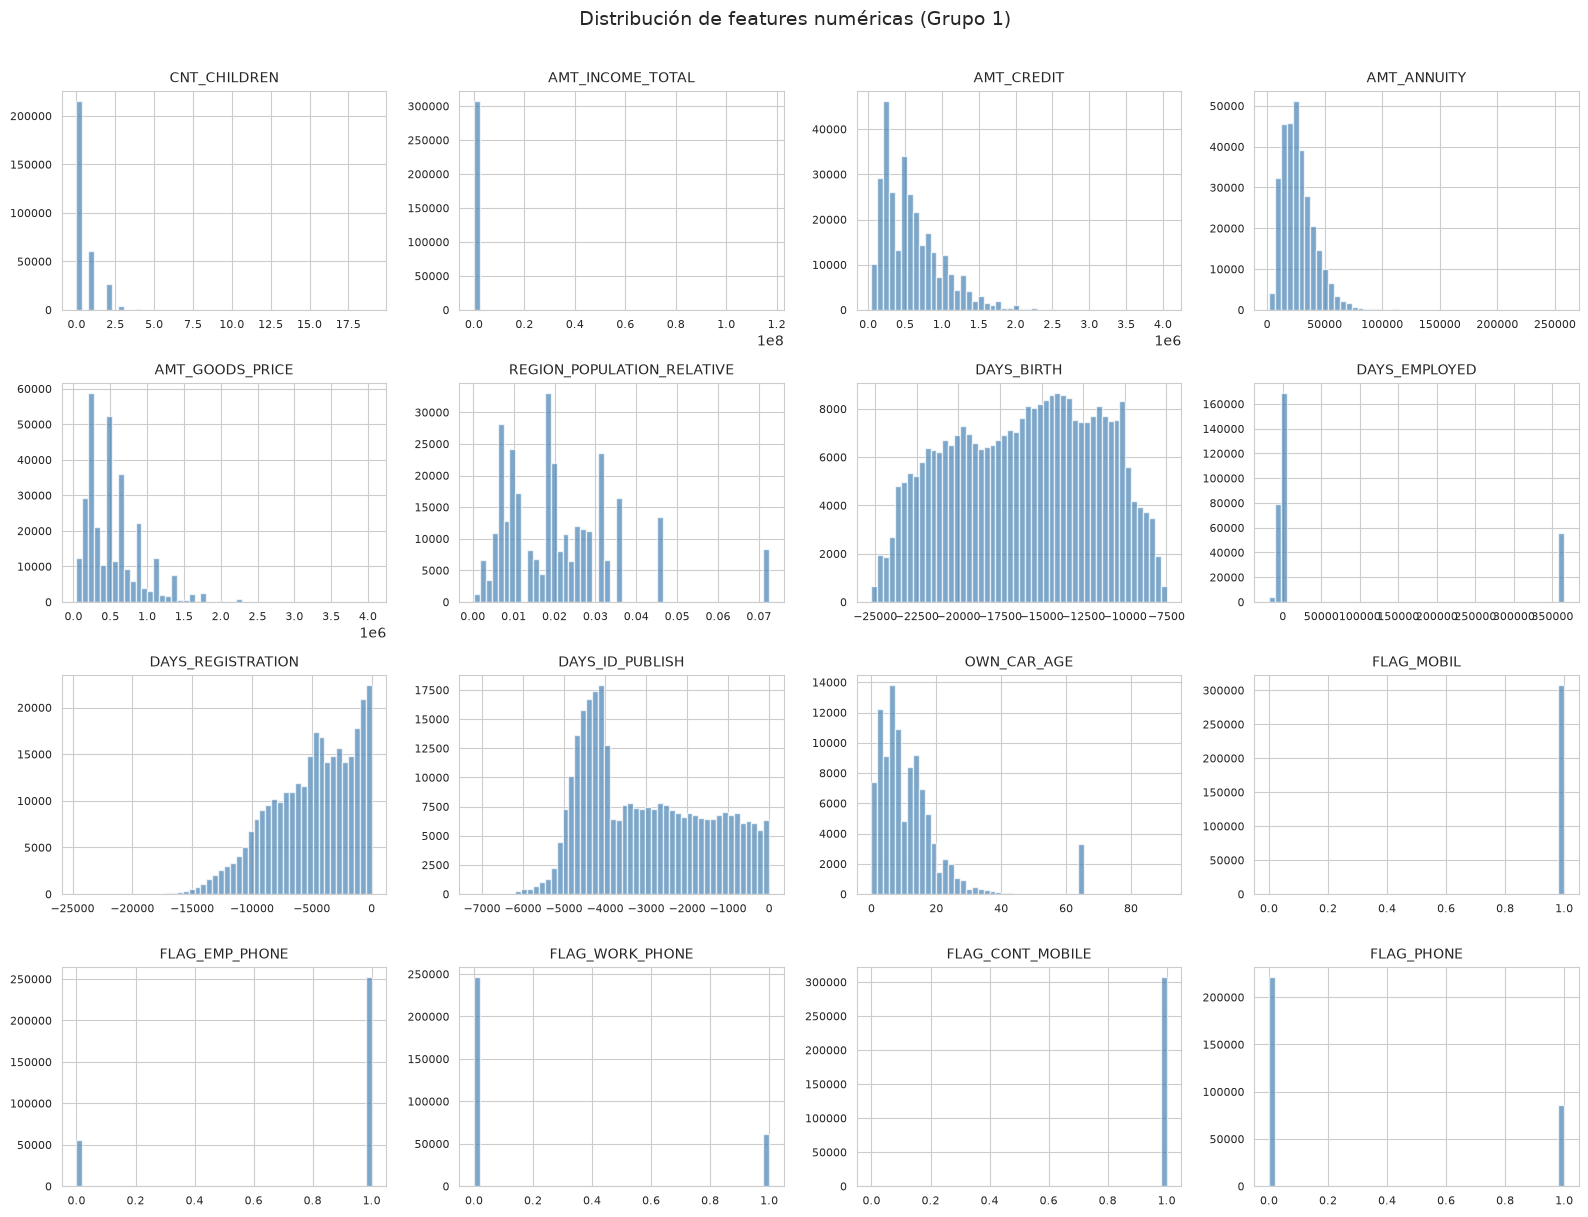

In [17]:
# Histogramas de las primeras 16 numéricas

n_cols = 4
n_rows = 4

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(num_cols[:16]):
    df[col].hist(bins=50, ax=axes[i], color='steelblue', edgecolor='white', alpha=0.7)
    axes[i].set_title(col, fontsize=10)
    axes[i].tick_params(labelsize=8)

# Ocultar ejes vacíos
for j in range(16, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribución de features numéricas (Grupo 1)', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

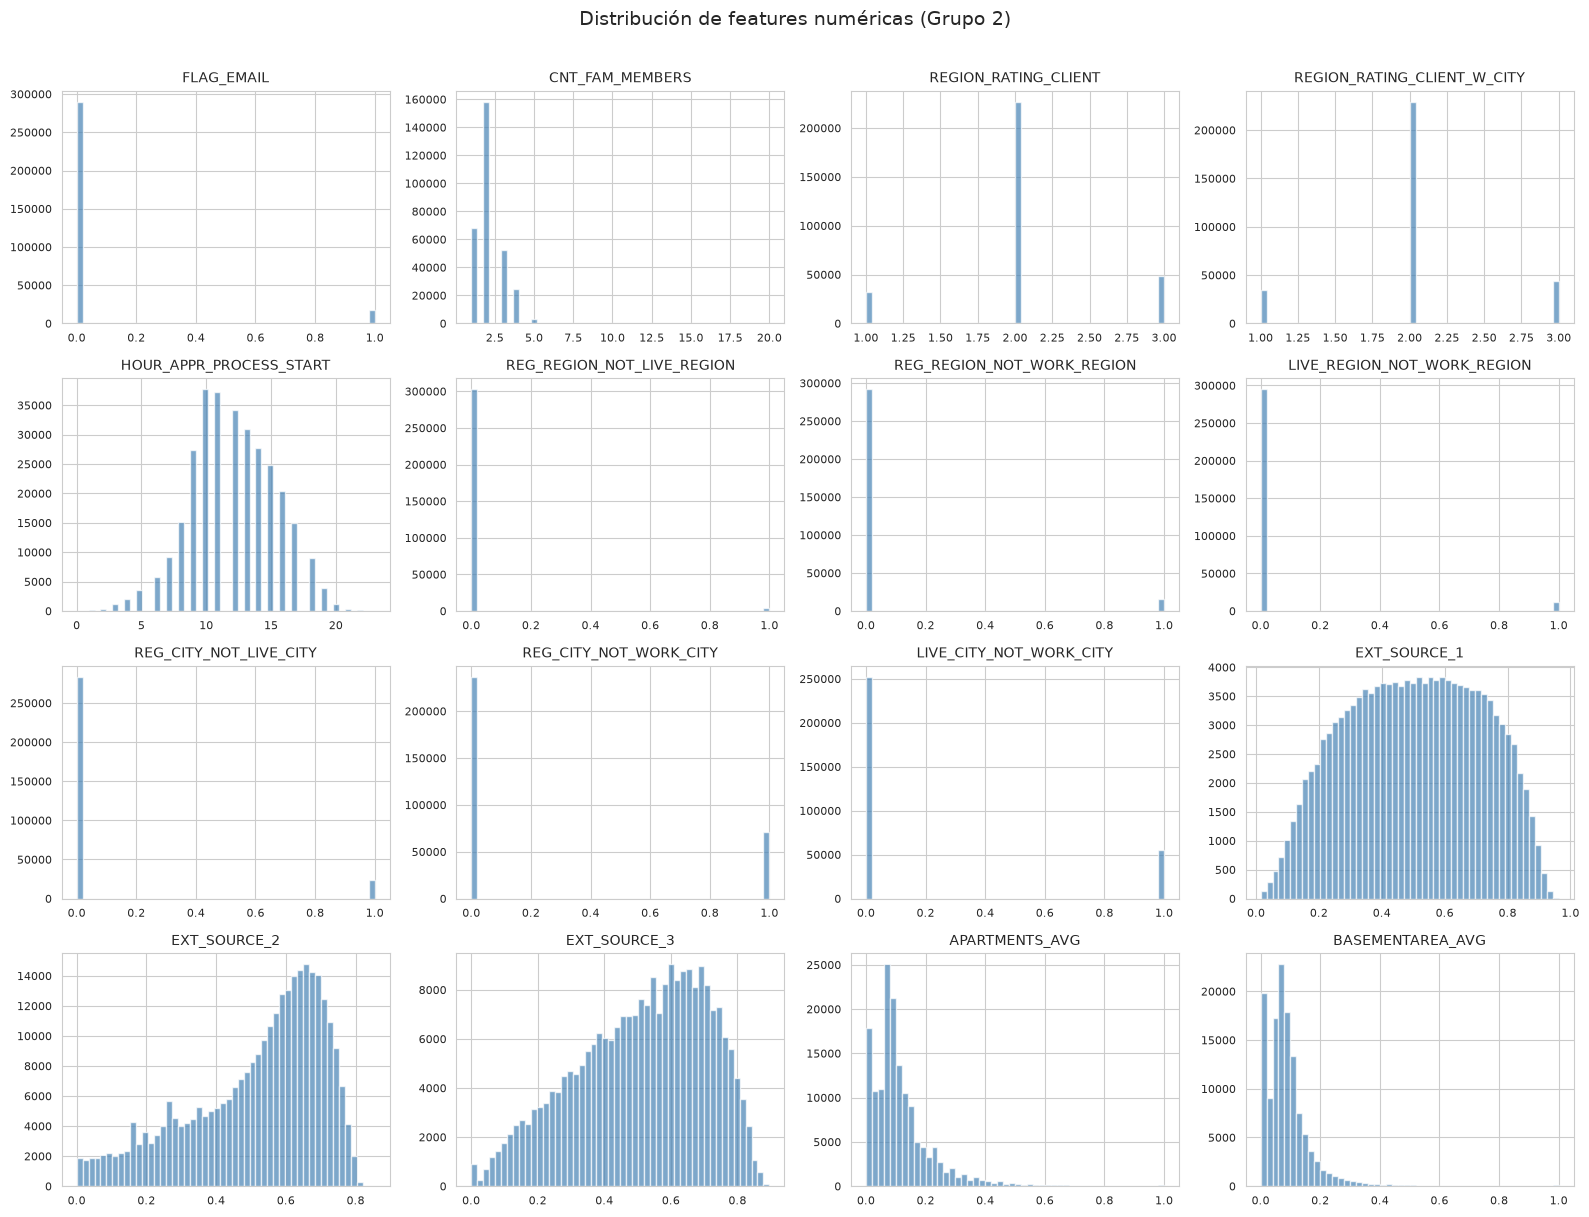

In [18]:
# Grupo 2: numéricas 17-32
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(num_cols[16:32]):
    df[col].hist(bins=50, ax=axes[i], color='steelblue', edgecolor='white', alpha=0.7)
    axes[i].set_title(col, fontsize=10)
    axes[i].tick_params(labelsize=8)

for j in range(len(num_cols[16:32]), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribución de features numéricas (Grupo 2)', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

In [21]:
# Skewness de las numéricas — para identificar distribuciones muy sesgadas
skewness = df[num_cols].skew().sort_values(ascending=False)

print('Top 15 features con mayor skewness')
print(skewness.head(15))

Top 15 features con mayor skewness
FLAG_DOCUMENT_12            392.1148
AMT_INCOME_TOTAL            391.5597
FLAG_DOCUMENT_10            209.5891
FLAG_DOCUMENT_2             153.7918
AMT_REQ_CREDIT_BUREAU_QRT   134.3658
FLAG_DOCUMENT_4             110.8944
FLAG_DOCUMENT_7              72.1741
FLAG_DOCUMENT_17             61.2141
FLAG_DOCUMENT_21             54.6129
FLAG_DOCUMENT_20             44.3649
FLAG_DOCUMENT_19             40.9561
FLAG_DOCUMENT_15             28.6993
AMT_REQ_CREDIT_BUREAU_DAY    27.0435
FLAG_DOCUMENT_14             18.3725
FLAG_DOCUMENT_13             16.7537
dtype: float64


---
## 7. Análisis univariado — Categóricas

Para cada feature categórica, vemos la distribución de categorías.

In [23]:
# Cuántas categorías tiene cada feature categórica
cat_unique = df[cat_cols].nunique().sort_values(ascending=False)

print('Categorías por feature:')
for col, n in cat_unique.items():
    print(f'  {col:30s} : {n} categorías')

Categorías por feature:
  ORGANIZATION_TYPE              : 58 categorías
  OCCUPATION_TYPE                : 18 categorías
  NAME_INCOME_TYPE               : 8 categorías
  NAME_TYPE_SUITE                : 7 categorías
  WALLSMATERIAL_MODE             : 7 categorías
  WEEKDAY_APPR_PROCESS_START     : 7 categorías
  NAME_FAMILY_STATUS             : 6 categorías
  NAME_HOUSING_TYPE              : 6 categorías
  NAME_EDUCATION_TYPE            : 5 categorías
  FONDKAPREMONT_MODE             : 4 categorías
  HOUSETYPE_MODE                 : 3 categorías
  CODE_GENDER                    : 3 categorías
  FLAG_OWN_CAR                   : 2 categorías
  NAME_CONTRACT_TYPE             : 2 categorías
  FLAG_OWN_REALTY                : 2 categorías
  EMERGENCYSTATE_MODE            : 2 categorías


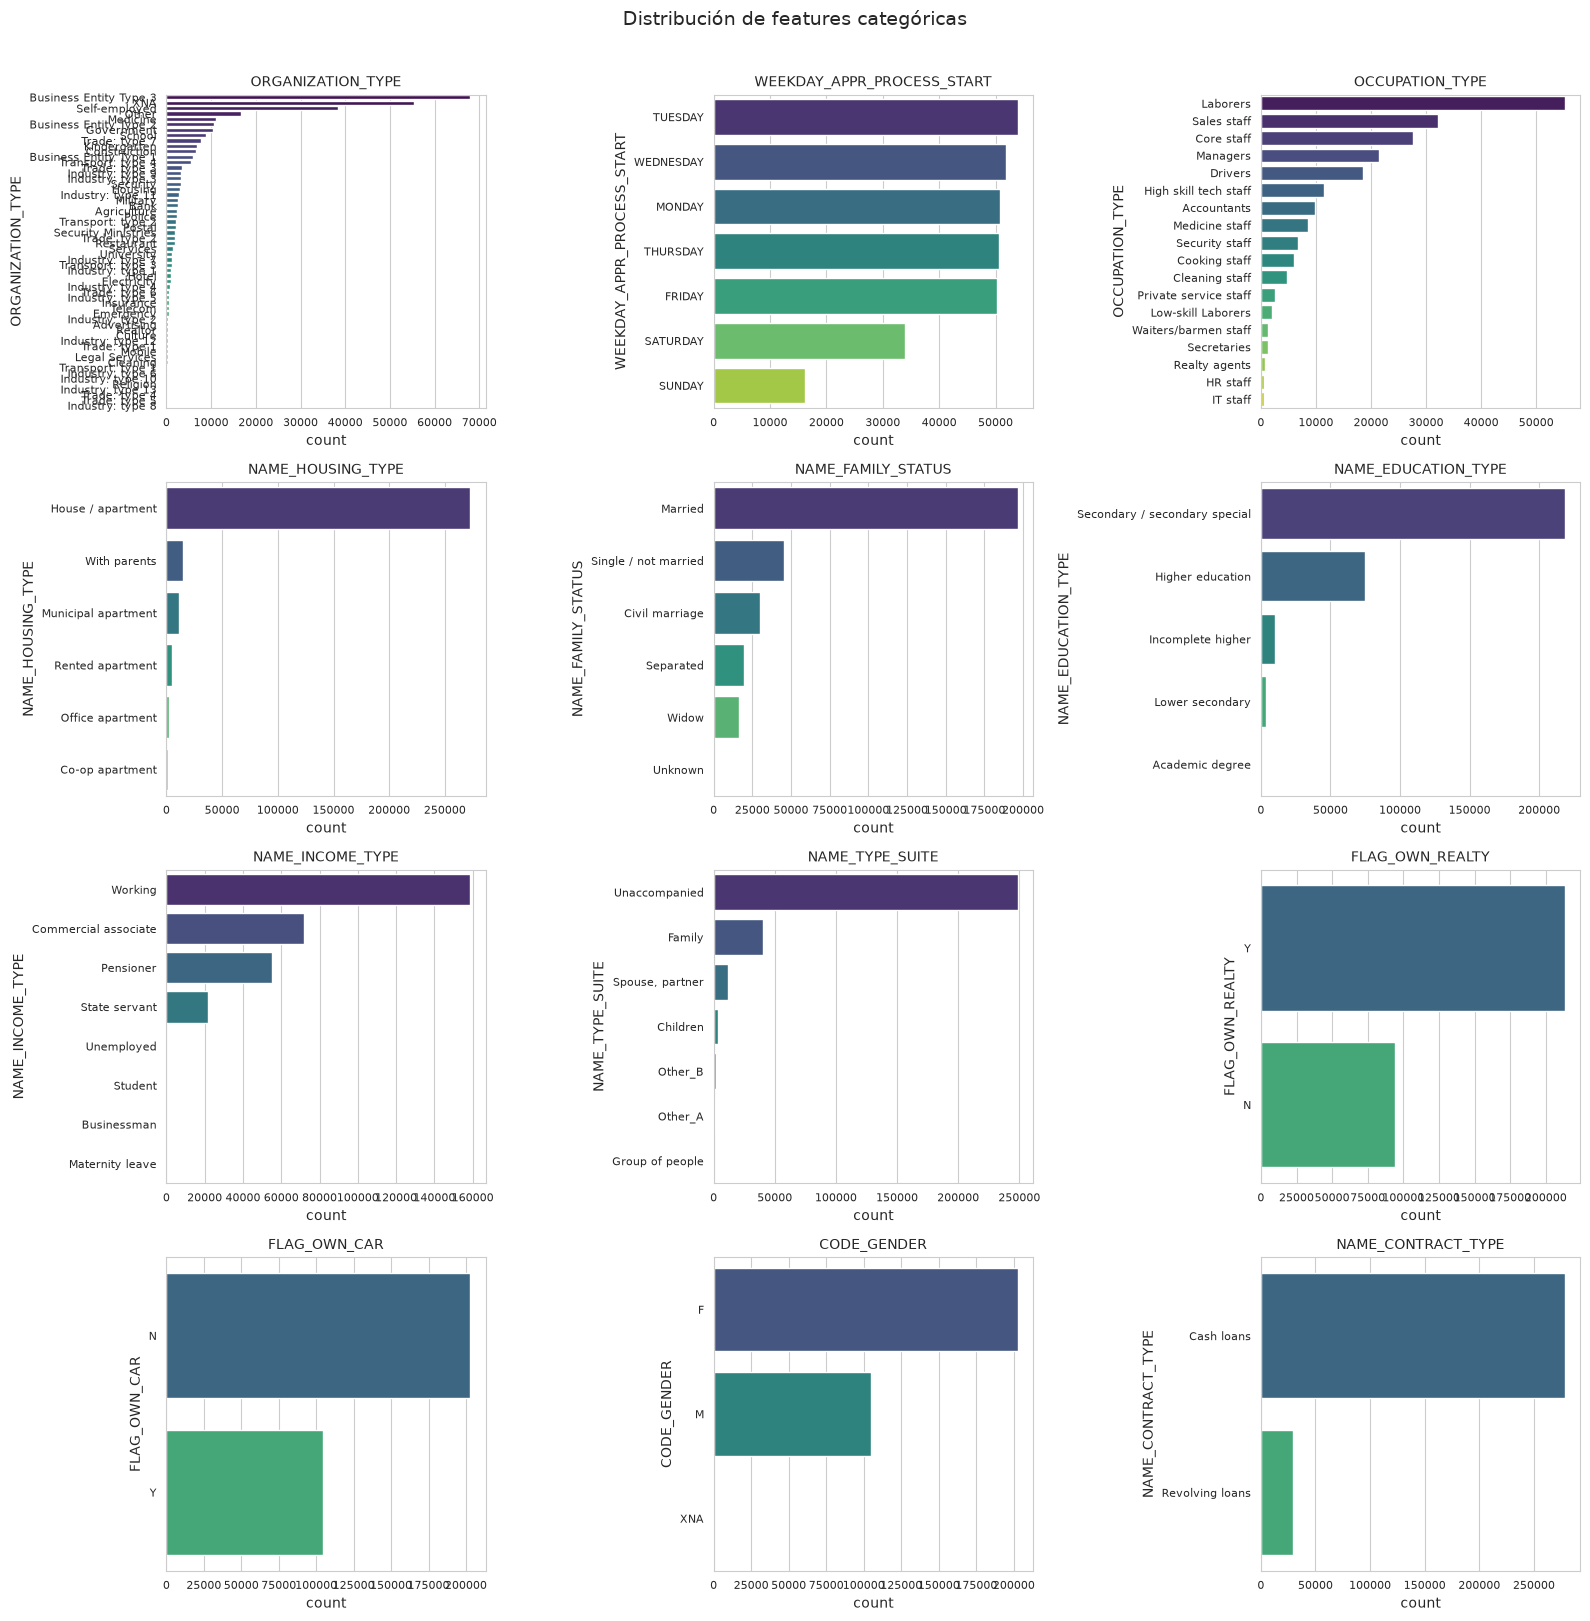

In [25]:
# Countplots de las categóricas (hasta 12)
plot_cols = cat_cols[:12][::-1]
n_cols = 3
n_rows = (len(plot_cols) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 4))
axes = axes.flatten()

for i, col in enumerate(plot_cols):
    order = df[col].value_counts().index
    sns.countplot(y=df[col], order=order, ax=axes[i], palette='viridis')
    axes[i].set_title(col, fontsize=10)
    axes[i].tick_params(labelsize=8)

for j in range(len(plot_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribución de features categóricas', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

---
## 8. Correlaciones con la TARGET

**Nota:** La correlación de Pearson solo captura relaciones lineales y además no significa causalidad.

In [26]:
# Correlaciones con la TARGET
corr_with_target = df[num_cols + [TARGET_COL]].corr()[TARGET_COL].drop(TARGET_COL)

# Top 15 positivas y negativas
print('=== TOP 15 POSITIVAS (mayor riesgo de default) ===')
print(corr_with_target.sort_values(ascending=False).head(15))
print()
print('=== TOP 15 NEGATIVAS (menor riesgo de default) ===')
print(corr_with_target.sort_values(ascending=True).head(15))

=== TOP 15 POSITIVAS (mayor riesgo de default) ===
DAYS_BIRTH                    0.0782
REGION_RATING_CLIENT_W_CITY   0.0609
REGION_RATING_CLIENT          0.0589
DAYS_LAST_PHONE_CHANGE        0.0552
DAYS_ID_PUBLISH               0.0515
REG_CITY_NOT_WORK_CITY        0.0510
FLAG_EMP_PHONE                0.0460
REG_CITY_NOT_LIVE_CITY        0.0444
FLAG_DOCUMENT_3               0.0443
DAYS_REGISTRATION             0.0420
OWN_CAR_AGE                   0.0376
LIVE_CITY_NOT_WORK_CITY       0.0325
DEF_30_CNT_SOCIAL_CIRCLE      0.0322
DEF_60_CNT_SOCIAL_CIRCLE      0.0313
FLAG_WORK_PHONE               0.0285
Name: TARGET, dtype: float64

=== TOP 15 NEGATIVAS (menor riesgo de default) ===
EXT_SOURCE_3                 -0.1789
EXT_SOURCE_2                 -0.1605
EXT_SOURCE_1                 -0.1553
DAYS_EMPLOYED                -0.0449
FLOORSMAX_AVG                -0.0440
FLOORSMAX_MEDI               -0.0438
FLOORSMAX_MODE               -0.0432
AMT_GOODS_PRICE              -0.0396
REGION_POPULATION

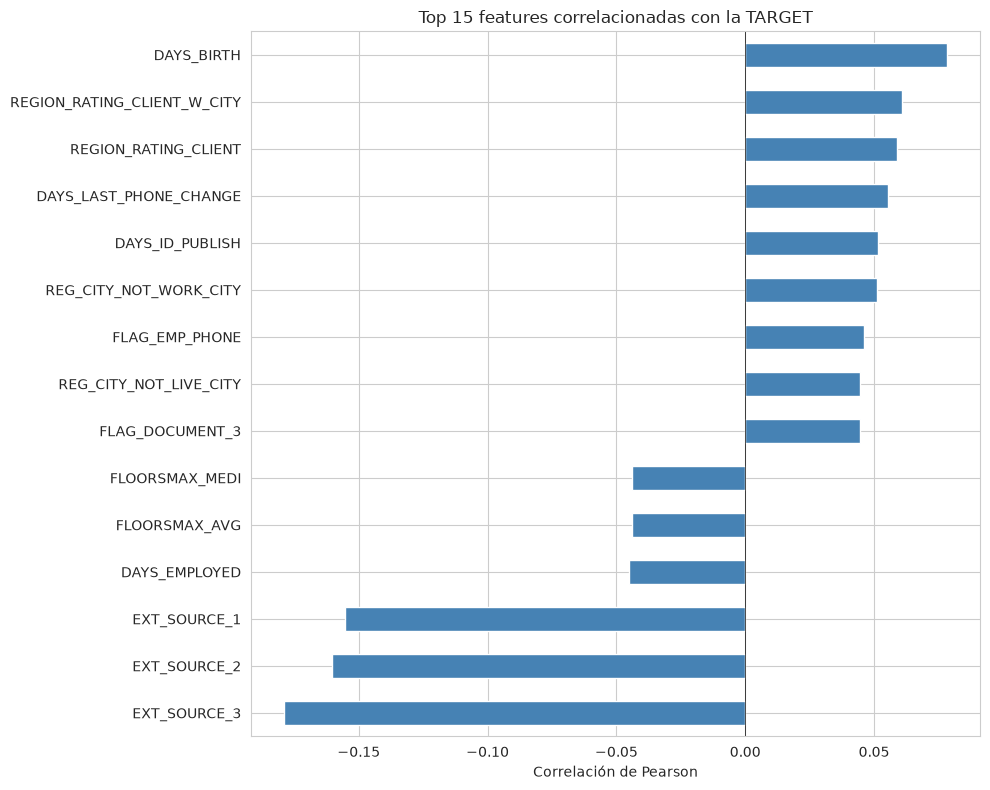

In [27]:
# Visualización de las 15 correlaciones más fuertes (abs)
top_corr = corr_with_target.abs().sort_values(ascending=False).head(15)
top_features = top_corr.index.tolist()

fig, ax = plt.subplots(figsize=(10, 8))
corr_with_target[top_features].sort_values().plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('Top 15 features correlacionadas con la TARGET')
ax.set_xlabel('Correlación de Pearson')
ax.axvline(x=0, color='black', linewidth=0.5)
plt.tight_layout()
plt.show()

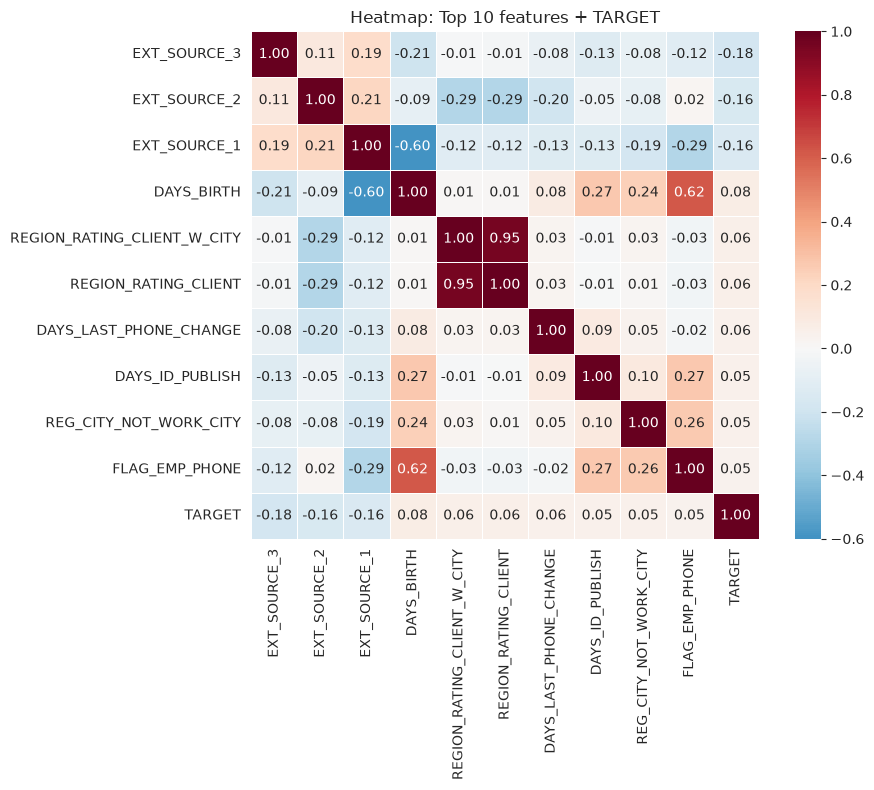

In [28]:
# Heatmap de las features más correlacionadas entre sí
# (para detectar multicolinealidad)
top_n = 10
top_features_for_heatmap = corr_with_target.abs().sort_values(ascending=False).head(top_n).index.tolist()
top_features_for_heatmap.append(TARGET_COL)

fig, ax = plt.subplots(figsize=(10, 8))
corr_matrix = df[top_features_for_heatmap].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            square=True, linewidths=0.5, ax=ax)
ax.set_title(f'Heatmap: Top {top_n} features + TARGET')
plt.tight_layout()
plt.show()

---
## 9. Hallazgos y conclusiones

In [ ]:
print('EJECUTIVO DEL EDA - Paso 1')
print('=' * 50)
print()
print('1. ESTRUCTURA:')
print(f'   - {df.shape[0]:,} solicitudes, {df.shape[1]} features')
print(f'   - {len(num_cols)} numéricas, {len(cat_cols)} categóricas')
print()
print('2. CALIDAD:')
print(f'   - {len(null_df)} columnas con nulos')
print(f'   - {dups} filas duplicadas')
print(f'   - {len(const_cols)} columnas constantes')
print()
print('3. TARGET:')
print(f'   - Ratio: 1:{target_counts[0]//target_counts[1]}')
print(f'   - Desbalanceo: {" Severo" if target_pct[1] < 10 else " Moderado"}')
print()
print('4. TOP CORRELACIONES CON TARGET:')
top5 = corr_with_target.abs().sort_values(ascending=False).head(5)
for feat, val in top5.items():
    direction = '+' if corr_with_target[feat] > 0 else '-'
    print(f'   - {feat}: {direction}{val:.4f}')
print()
print('5. PRÓXIMOS PASOS:')
print('   - Paso 2: Enriquecer con bureau.csv (créditos externos)')
print('   - Paso 3: Agregar previous_application.csv')

EJECUTIVO DEL EDA - Paso 1

1. ESTRUCTURA:
   - 307,511 solicitudes, 122 features
   - 104 numéricas, 16 categóricas

2. CALIDAD:
   - 67 columnas con nulos
   - 0 filas duplicadas
   - 0 columnas constantes

3. TARGET:
   - Ratio: 1:11
   - Desbalanceo:  Severo

4. TOP CORRELACIONES CON TARGET:
   - EXT_SOURCE_3: -0.1789
   - EXT_SOURCE_2: -0.1605
   - EXT_SOURCE_1: -0.1553
   - DAYS_BIRTH: +0.0782
   - REGION_RATING_CLIENT_W_CITY: +0.0609

5. PRÓXIMOS PASOS:
   - Paso 2: Enriquecer con bureau.csv (créditos externos)
   - Paso 3: Agregar previous_application.csv
